# OpenPOPCON Stellarator example
Welcome! This is an example usage of the OpenPOPCON scoping tool for the [MANTA](https://iopscience.iop.org/article/10.1088/1361-6587/ad6708) tokamak.

In [36]:
# !pip install --force-reinstall numpy==2.0.0
%matplotlib inline
import numpy as np
print(np.__version__)

1.26.4


In [37]:
import sys
import pathlib
OP_HOME = '../../../'
sys.path.append(str(pathlib.Path(OP_HOME).resolve())) 
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# ^^^ This must be done to import the openpopcon module from the src directory.
# When running this from another directory, change the OP_HOME variable to the
# path of the openpopcon directory.
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
import numpy as np
from src import openpopcon as op

%reload_ext autoreload
%autoreload 2

## Setup
The POPCON object requires three settings files in the yaml format.
The first, 'settingsfile', contains the physical parameters for the tokamak, as well as algorithm information. 
The second, 'plotsettingsfile', contains the settings for the plots. This can be updated after plotting to change the appearance of the plots, without restarting the jupyter notebook.
The third, 'scalinglawfile', you will not necessarily need to change, but it contains the confinement time $\tau_E$ scaling laws for the simulation.

When you run this on your own, it is recommended that you copy the first two settings files and modify them to suit your needs; you can leave scalinglawfile as is.

In [38]:
settingsfile = "./Stellarator_example.yaml"
plotsettingsfile = "./plotsettings.yml"
scalinglawfile = f"{OP_HOME}/resources/scalinglaws.yml"

pc = op.POPCON(settingsfile=settingsfile, 
               plotsettingsfile=plotsettingsfile, 
               scalinglawfile=scalinglawfile)

Impurity fractions = [0.025      0.         0.         0.00122461 0.         0.        ] calculated from Zeff_target.


In [39]:
print(pc.settings.device_type)

stellarator


## Running the code

To run the code, simply run the cell below. This will run the simulation.

OpenPOPCON uses numba 'just in time' (jit) compilation to speed up the simulation. This means that the first time you run the simulation, it will take a little longer to compile the code. Subsequent runs will be faster, until you restart the jupyter notebook kernel, at which the compilation will be required again.

In [42]:
# This runs the POPCON
pc.run_POPCON()

✓ Loaded geometry from gEQDSK file: gMANTA
Setting up algorithm object
Setting up algorithm object
Solving power balance equations
Solving power balance equations
Running n20=Running n20= 1.5455978807577357 , T= 19.440155725655373  keV
Running n20= 1.7948878615251125 , T= 19.440155725655373  keV
Running n20= 1.296307899990359 , T= 19.440155725655373  keV
Running n20= 2.293467823059866 , T= 19.440155725655373  keV
Running n20= 2.7920477845946197 , T= 19.440155725655373  keV
Running n20= 3.0413377653619964 , T= 19.440155725655373  keV
Running n20= 2.542757803827243 , T= 19.440155725655373  keV
Running n20= 3.290627746129373 , T= 19.440155725655373  keV
Running n20= 2.0441778422924894 , T= 19.440155725655373  keV
 1.0470179192229823 , T= 19.440155725655373  keV
Running n20= 1.5455978807577357 , T= 19.77077061894883  keV
Running n20= 1.296307899990359 , T= 19.77077061894883  keV
Running n20= 1.7948878615251125 , T= 19.77077061894883  keV
Running n20= 2.293467823059866 , T= 19.7707706189488

## Plotting
The POPCON object has a method, 'plot', which will plot the results of the simulation. This method takes the settings from the 'plotsettingsfile' and plots the results. You can modify the 'plotsettingsfile' and rerun both 'update_plotsettings' and the plot method to see the changes.

There is also the method 'custom_plot' which allows you to plot any array on top of the simulation results. This can be useful if you have a specific quantity that is not calculated by default.

Paux min: 468.2471709373896, max: 8745.187417522122, levels: 10
Plotting Paux with levels [ 472.92964265 1382.3525205  2291.77539836 3201.19827621 4110.62115407
 5020.04403192 5929.46690978 6838.88978764 7748.31266549 8657.73554335] and options ['r', 3, '$P_{aux}$', 12, '%.2d']
Plotting Pfusion with levels [ 100.  200.  500. 1000. 2000. 4000.] and options ['k', 2, '$P_{fus}$', 12, '%.2d']
Plotting Prad with levels [ 10.  50. 100. 200.] and options ['purple', 2, '$P_{rad}$', 12, '%.2d']
Plotting Q with levels [  0.5   1.    2.    5.   10.   25.   50.  100. ] and options ['orange', 2, '$Q$', 12, '%.f']
H89 min: 0.2053316126430092, max: 0.3595086052893472, levels: 10
Plotting H89 with levels [0.20738493 0.22388811 0.24039128 0.25689446 0.27339764 0.28990081
 0.30640399 0.32290717 0.33941034 0.35591352] and options ['blue', 2, '$H_{89}$', 12, '%.2f']
betaN min: 0.5944303800297003, max: 3.6315542586606284, levels: 5
Plotting betaN with levels [0.60037468 1.34909069 2.0978067  2.84652271 3.5

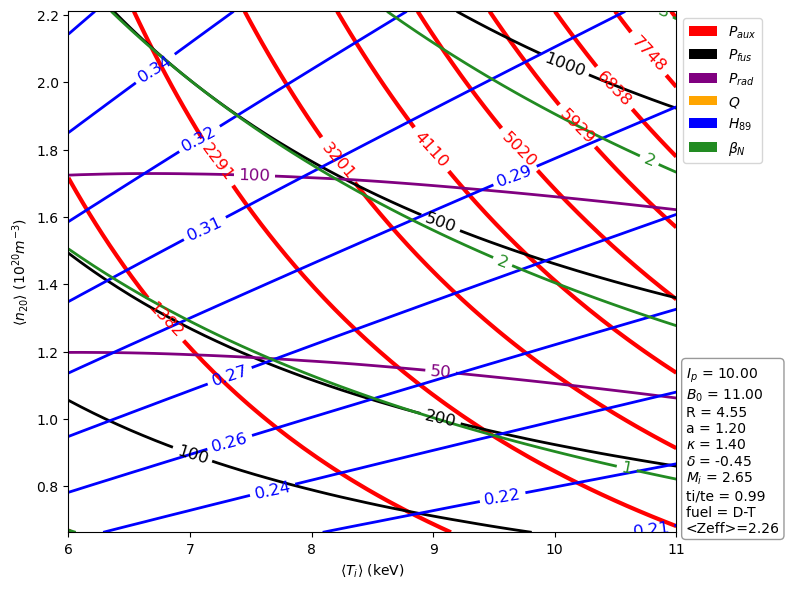

/var/folders/bl/8rkrmzbx1qd37t786tbc1m0w0000gn/T/ipykernel_37400/2731424169.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [ ]:
pc.update_plotsettings()
fig, ax = pc.plot()

# Example of how to plot a custom quantity
P_synchotron = np.empty((pc.settings.Nn, pc.settings.NTi))
rho = pc.algorithms.sqrtpsin
for i in range(pc.settings.Nn):
    for j in range(pc.settings.NTi):
        P_synchotron[i,j] = pc.algorithms.volume_integral(rho, pc.algorithms._P_brem_rad(rho, pc.output.T_e_max[j], pc.output.n_e_20_max[i]))
pc.custom_plot(fig, ax, P_synchotron, np.linspace(np.min(P_synchotron), np.max(P_synchotron), 5), 'teal', 1., r'$P_{synch}$')
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
fig.show()

## Scoping operation points

POPCONs, or 'Plasma OPerating CONtours', show a wide range of operating points for a given tokamak. The 'single_point' method lets you explore a single pair of density/temperatures, and look at the resulting profiles. 


Params:
n_i_average = 1.7808751218812529 x 10^20 m^-3
n_e_average = 1.945 x 10^20 m^-3
n_G = 2.210 x 10^20 m^-3
n_i_axis = 2.790 x 10^20 m^-3
n_e_axis = 3.047 x 10^20 m^-3
Ti_average = 7.3 keV
Ti_axis = 23.3 keV
Solution:
P_aux = 2630.76 MW
P_fusion = 510.67 MW
P_SOL = 2613.90 MW
P_load = 9.800 MW/m^2
P_ohmic = 1.045 MW
P_brems = 27.142 MW
P_synch = 8.183 MW
P_imprad = 90.098 MW
P_rad = 125.42 MW
P_heat = 2707.19 MW
P_alpha = 102.13 MW
P_dd = 0.594 MW
P_dt = 510.08 MW
Wtot/TauE = 2704.00 MW
f_rad = 0.046 
tauE = 0.047 s
Q = 0.194 
H89 = 0.33
H98 = 0.30
vloop = 0.1045 V
betaN = 2.121



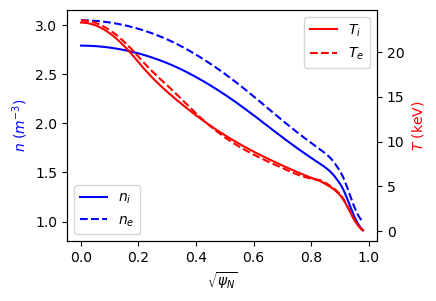

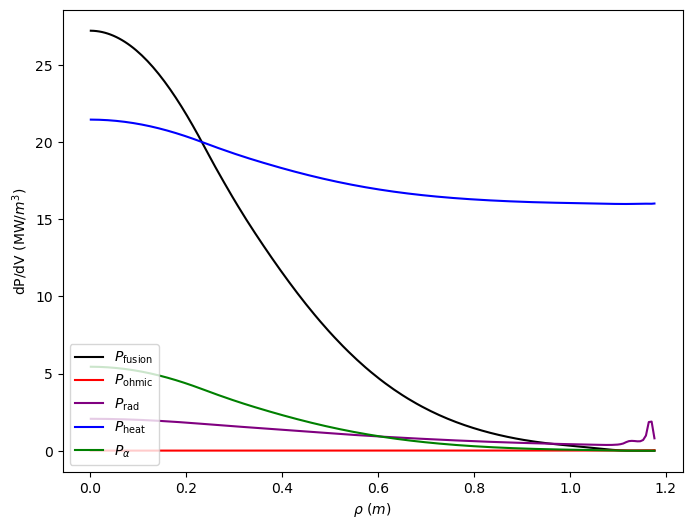

In [ ]:
pc.single_point(n_G_frac=0.88,Ti_av=7.3)

## Reading and writing outputs

Running this simulation large quantities of times can be time consuming. Saving and loading of POPCON outputs is enabled so that you can save the results of a simulation and load them later to edit the plots. Outputs are saved to the 'outputs' directory as either a folder or a zip archive. See below.

In [ ]:
pc.write_output(name='test',archive=False,overwrite=True)
# Had to build own output file underneath OpenPOPCON directory

Paux min: 468.2471709373896, max: 8745.187417522122, levels: 10
Plotting Paux with levels [ 472.92964265 1382.3525205  2291.77539836 3201.19827621 4110.62115407
 5020.04403192 5929.46690978 6838.88978764 7748.31266549 8657.73554335] and options ['r', 3, '$P_{aux}$', 12, '%.2d']
Plotting Pfusion with levels [ 100.  200.  500. 1000. 2000. 4000.] and options ['k', 2, '$P_{fus}$', 12, '%.2d']
Plotting Prad with levels [ 10.  50. 100. 200.] and options ['purple', 2, '$P_{rad}$', 12, '%.2d']
Plotting Q with levels [  0.5   1.    2.    5.   10.   25.   50.  100. ] and options ['orange', 2, '$Q$', 12, '%.f']
H89 min: 0.2053316126430092, max: 0.3595086052893472, levels: 10
Plotting H89 with levels [0.20738493 0.22388811 0.24039128 0.25689446 0.27339764 0.28990081
 0.30640399 0.32290717 0.33941034 0.35591352] and options ['blue', 2, '$H_{89}$', 12, '%.2f']
betaN min: 0.5944303800297003, max: 3.6315542586606284, levels: 5
Plotting betaN with levels [0.60037468 1.34909069 2.0978067  2.84652271 3.5

Impurity fractions = [0.025      0.         0.         0.00122461 0.         0.        ] calculated from Zeff_target.
Impurity fractions = [0.025      0.         0.         0.00122461 0.         0.        ] calculated from Zeff_target.
gEQDSK geometry:
Minor radius: 1.1994801681532419
Major radius: 4.550482081828347
Elongation: 1.39990598739843
Triangularity: -0.4490115238844408
z0: -1.3209168668870674e-06
gEQDSK Ip: 10.001901131483173
Len of psin: 50
Len of sqrtpsin: 200
Len of volgrid: 200
Len of jrms: 200
Len of qr: 200
Len of agrid: 200
Len of ftrapped_profile: 200
(200,)
Paux min: 468.2471709373896, max: 8745.187417522122, levels: 10
Plotting Paux with levels [ 472.92964265 1382.3525205  2291.77539836 3201.19827621 4110.62115407
 5020.04403192 5929.46690978 6838.88978764 7748.31266549 8657.73554335] and options ['r', 3, '$P_{aux}$', 12, '%.2d']
Plotting Pfusion with levels [ 100.  200.  500. 1000. 2000. 4000.] and options ['k', 2, '$P_{fus}$', 12, '%.2d']
Plotting Prad with levels

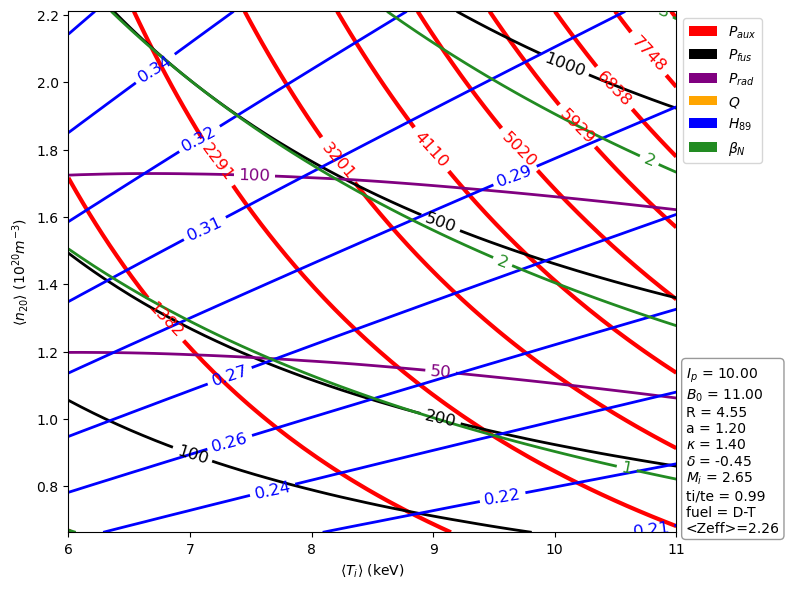

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='$\\langle T_i\\rangle$ (keV)', ylabel='$\\langle n_{20}\\rangle$ ($10^{20} m^{-3}$)'>)

In [ ]:
pcread = op.POPCON(settingsfile=settingsfile,
                   plotsettingsfile=plotsettingsfile,
                   scalinglawfile=scalinglawfile)
pcread.read_output('test')
pcread.plot()

In [ ]:
print("iota_23 from VMEC:", pc.settings.iota_23)
print("rho grid from VMEC:", pc.algorithms.sqrtpsin)

iota_23 from VMEC: 0.7
rho grid from VMEC: [0.001      0.0059196  0.0108392  0.01575879 0.02067839 0.02559799
 0.03051759 0.03543719 0.04035678 0.04527638 0.05019598 0.05511558
 0.06003518 0.06495477 0.06987437 0.07479397 0.07971357 0.08463317
 0.08955276 0.09447236 0.09939196 0.10431156 0.10923116 0.11415075
 0.11907035 0.12398995 0.12890955 0.13382915 0.13874874 0.14366834
 0.14858794 0.15350754 0.15842714 0.16334673 0.16826633 0.17318593
 0.17810553 0.18302513 0.18794472 0.19286432 0.19778392 0.20270352
 0.20762312 0.21254271 0.21746231 0.22238191 0.22730151 0.23222111
 0.2371407  0.2420603  0.2469799  0.2518995  0.2568191  0.26173869
 0.26665829 0.27157789 0.27649749 0.28141709 0.28633668 0.29125628
 0.29617588 0.30109548 0.30601508 0.31093467 0.31585427 0.32077387
 0.32569347 0.33061307 0.33553266 0.34045226 0.34537186 0.35029146
 0.35521106 0.36013065 0.36505025 0.36996985 0.37488945 0.37980905
 0.38472864 0.38964824 0.39456784 0.39948744 0.40440704 0.40932663
 0.41424623 0.41916

=== Coordinate System Analysis ===
Reading VMEC equilibrium from: ../../../src/lib/wout_2007_000_000000.nc
✓ Successfully read VMEC file with 100 flux surfaces, 81 modes
  - Major radius: 1.779 m
  - Minor radius: 0.746 m
  - Volume: 19.559 m³
  - Volume averaged |B|: 13.064 T
  - Toroidal current density range: 0.00e+00 to 6.72e+06 A/m²
✓ Computed geometric quantities:
  - Toroidal field Ba: 13.077 T
  - Surface areas computed for 100 surfaces
  - Current density computed
Max coordinate difference: 0.0000
RMS coordinate difference: 0.0000
Average iota: 0.5765
Recommendation: Use sqrt(toroidal flux) for stellarators as implemented in VMEC
Note: VMEC natively uses sqrt(normalized toroidal flux) which is appropriate for stellarators
  - Toroidal current density range: 0.00e+00 to 6.72e+06 A/m²
✓ Computed geometric quantities:
  - Toroidal field Ba: 13.077 T
  - Surface areas computed for 100 surfaces
  - Current density computed
Max coordinate difference: 0.0000
RMS coordinate difference

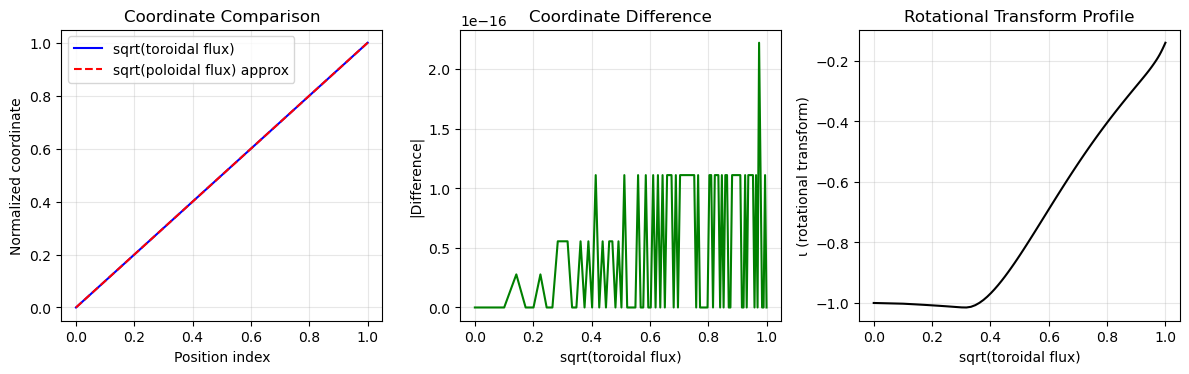


Conclusion: VMEC natively uses sqrt(toroidal flux) which is appropriate for stellarators
The coordinate difference is small (max: 0.0000) for this equilibrium


In [ ]:
# Test coordinate system comparison for stellarators
# This compares sqrt(poloidal flux) vs sqrt(toroidal flux) coordinates
try:
    import sys
    import pathlib
    OP_HOME = '../../../'
    sys.path.append(str(pathlib.Path(OP_HOME).resolve())) 
    
    from src.vmec_reader import VMECReader
    import os
    
    # Try to load a VMEC file for coordinate comparison
    vmec_file = os.path.join('..', '..', '..', 'src', 'lib', 'wout_2007_000_000000.nc')
    
    if os.path.exists(vmec_file):
        print("=== Coordinate System Analysis ===")
        vmec = VMECReader(vmec_file)
        
        # Get coordinate comparison
        coord_analysis = vmec.get_coordinate_comparison()
        
        print(f"Max coordinate difference: {coord_analysis['max_difference']:.4f}")
        print(f"RMS coordinate difference: {coord_analysis['rms_difference']:.4f}")
        print(f"Average iota: {coord_analysis['iota_avg']:.4f}")
        print(f"Recommendation: {coord_analysis['recommendation']}")
        print(f"Note: {coord_analysis['note']}")
        
        # Plot comparison
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 3, 1)
        plt.plot(coord_analysis['rho_toroidal'], coord_analysis['rho_toroidal'], 'b-', label='sqrt(toroidal flux)')
        plt.plot(coord_analysis['rho_toroidal'], coord_analysis['rho_poloidal_approx'], 'r--', label='sqrt(poloidal flux) approx')
        plt.xlabel('Position index')
        plt.ylabel('Normalized coordinate')
        plt.title('Coordinate Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 2)
        plt.plot(coord_analysis['rho_toroidal'], coord_analysis['coordinate_difference'], 'g-')
        plt.xlabel('sqrt(toroidal flux)')
        plt.ylabel('|Difference|')
        plt.title('Coordinate Difference')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 3)
        plt.plot(coord_analysis['rho_toroidal'], coord_analysis['iota_profile'], 'k-')
        plt.xlabel('sqrt(toroidal flux)')
        plt.ylabel('ι (rotational transform)')
        plt.title('Rotational Transform Profile')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nConclusion: VMEC natively uses sqrt(toroidal flux) which is appropriate for stellarators")
        print(f"The coordinate difference is small (max: {coord_analysis['max_difference']:.4f}) for this equilibrium")
        
    else:
        print("VMEC file not available for coordinate analysis")
        
except Exception as e:
    print(f"Coordinate analysis not available: {e}")